In [1]:
import numpy as np
import torch

from fish_segmentation.dinov3 import (
    load_backbone,
    plot_detection_results,
    plot_regions_with_centers,
    run_dino_view,
    run_zoom_detector,
)
from fish_segmentation.paths import find_repo_root, load_env
from fish_segmentation.video_io import load_sampled_frames

load_env()
ROOT = find_repo_root()

device = "cuda" if torch.cuda.is_available() else "cpu"
DINO_LONG_SIDE = 1024
DINO_RESOLUTION_SCALE = 4.0
print(device)


cuda


In [2]:
model_id = "facebook/dinov3-vitl16-pretrain-lvd1689m"
model, processor = load_backbone(model_id, device=device)


Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

In [3]:
video_path = ROOT / "dataset" / "processed" / "20260813_213529_7f994a2f" / "video.mp4"
if not video_path.exists():
    video_path = ROOT / "data" / "test_media" / "dolphin_00.mp4"
print(f"Using video: {video_path}")
frames = load_sampled_frames(video_path=str(video_path), n_frames=3)


Using video: /workspace/fish-segmentation/dataset/processed/20260813_213529_7f994a2f/video.mp4


In [4]:
# coarse-to-fine: DINO at 4x the <=1024 view, zoom into interest zones from
# original pixels, re-detect at the same relative scale, and merge points.
results = []
for frame in frames:
    detections = run_zoom_detector(
        image=frame,
        model=model,
        processor=processor,
        long_side=DINO_LONG_SIDE,
        resolution_scale=DINO_RESOLUTION_SCALE,
    )
    results.append((frame, detections))

regions_per_frame = sum(len(d) for _, d in results) / len(results)
print(regions_per_frame)


28.666666666666668


coarse heatmap: shape=(2160, 3840), range=(0.000, 1.000), mask_pixels=19,561


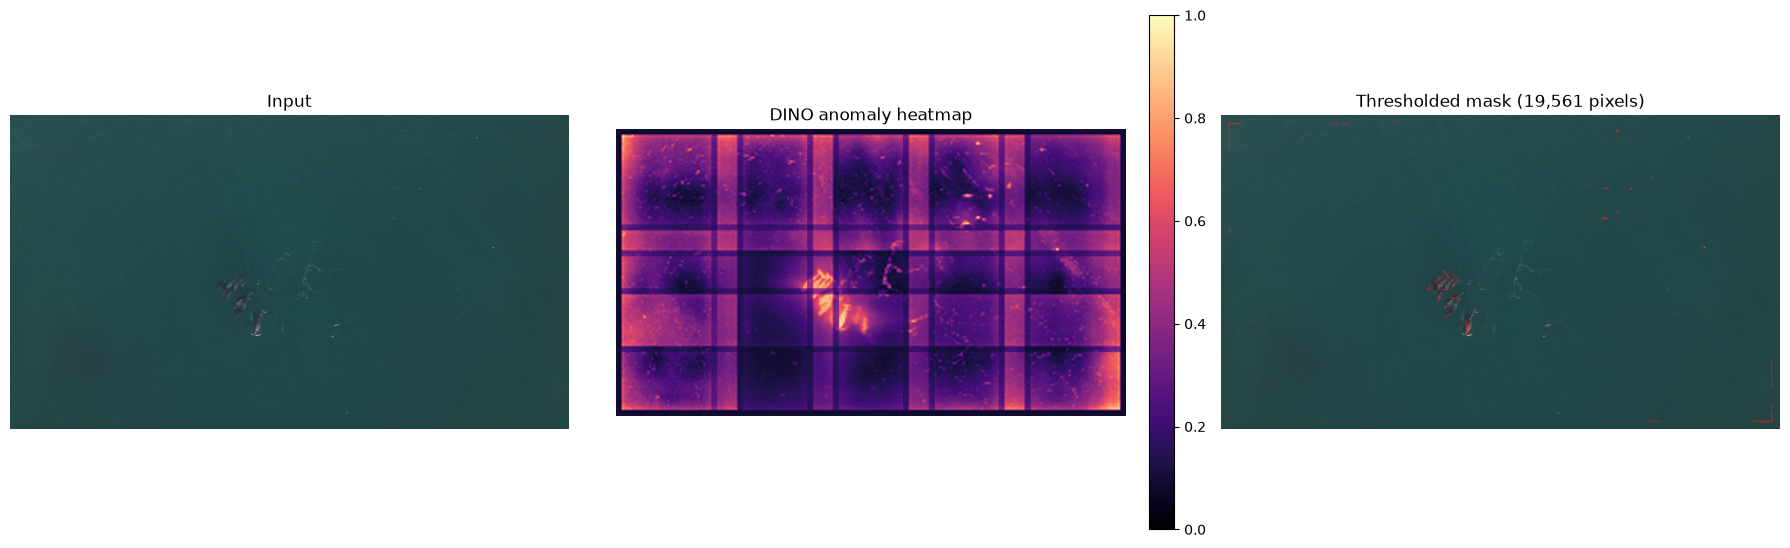

In [5]:
# Inspect the raw signal from the same scaled coarse pass used by the zoom detector.
diagnostic_frame = frames[len(frames) // 2]
coarse_mask, coarse_heatmap, cropped_frame = run_dino_view(
    image=diagnostic_frame,
    model=model,
    processor=processor,
    long_side=DINO_LONG_SIDE,
    resolution_scale=DINO_RESOLUTION_SCALE,
    percentile_threshold=99.5,
    device=device,
)
print(
    f"coarse heatmap: shape={coarse_heatmap.shape}, "
    f"range=({coarse_heatmap.min():.3f}, {coarse_heatmap.max():.3f}), "
    f"mask_pixels={np.count_nonzero(coarse_mask):,}"
)
plot_detection_results(cropped_frame, coarse_heatmap, coarse_mask)


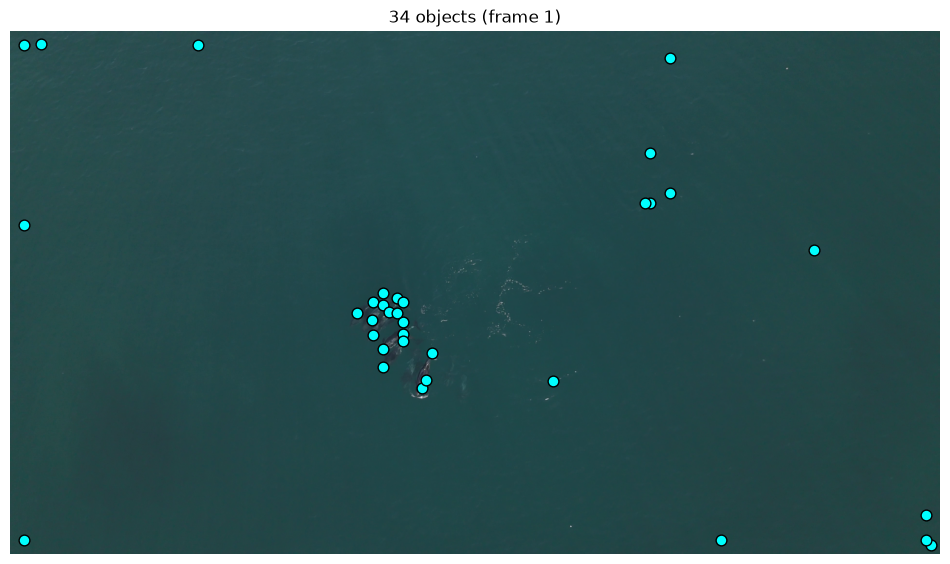

In [6]:
# visualize merged points on the full-res frame
import numpy as np

import matplotlib.pyplot as plt

frame, detections = results[1]
W, H = frame.size
fig, ax = plt.subplots(1, 1, figsize=(12, 7))
ax.imshow(frame)
for det in detections:
    cx, cy, r = det["x"] * W, det["y"] * H, det["radius"] * max(W, H)
    ax.scatter(cx, cy, c="cyan", edgecolors="black", s=60, zorder=5)
    ax.add_patch(plt.Circle((cx, cy), r, color="cyan", fill=False, linestyle="--", linewidth=1.2, alpha=0.8))
ax.set_title(f"{len(detections)} objects (frame {results.index((frame, detections))})")
ax.axis("off")
plt.show()


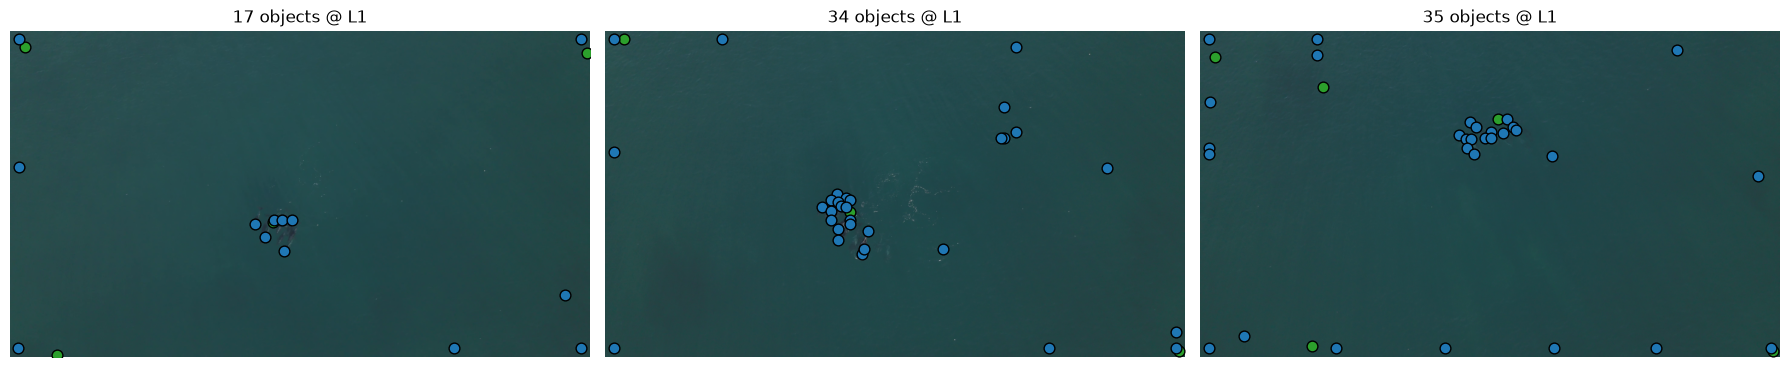

In [7]:
# visualize merged detections for all sampled frames (full-res, by level)
import matplotlib.pyplot as plt

LEVEL_COLORS = ["tab:blue", "tab:green", "tab:orange", "tab:red", "tab:purple"]

n = len(results)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 4), squeeze=False)
for ax, (frame, detections) in zip(axes[0], results):
    W, H = frame.size
    ax.imshow(frame)
    for det in detections:
        cx, cy, r = det["x"] * W, det["y"] * H, det["radius"] * max(W, H)
        col = LEVEL_COLORS[det["level"] % len(LEVEL_COLORS)]
        ax.scatter(cx, cy, c=col, edgecolors="black", s=60, zorder=5)
        ax.add_patch(plt.Circle((cx, cy), r, color=col, fill=False, linestyle=":", lw=1.2))
    ax.set_title(f"{len(detections)} objects @ L{max((d['level'] for d in detections), default=0)}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [8]:
!nvidia-smi

Sun Sep 13 22:12:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4090        On  |   00000000:81:00.0 Off |                  Off |
| 30%   37C    P2             53W /  450W |    1978MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----